In [1]:
from astropy.io import fits
import numpy as np
import math 
import matplotlib.pyplot as plt
from scipy.stats import skew

In [2]:
file = '/Users/jacob/Documents/Hawaii Research Project/master_files/master_file.fits'
hdul = fits.open(file)
data = hdul[1].data 

CFHT_windspeed = data['CFHT_windspeed']
CFHT_wind_direction = data['CFHT_wind_direction']
CFHT_temp = data['CFHT_temp']
CFHT_humidity = data['CFHT_humidity']
CFHT_pressure = data['CFHT_pressure']

## Doane's Rule

$$
k = 1 + \log_{2}(n) + \log_{2}(1 + \frac{|\text{skewness}|}{\sigma_{g1}})
$$
$$
k = \text{The number of bins}
$$
$$
n = \text{The number of data points}
$$
$$
\text{skewness = sample skewness of the data}
$$
$$
\sigma_{g1} = \sqrt{\frac{6(n-2)}{(n+1)(n+3)}} \text{(standard error of skewness)}
$$

In [24]:
def doane_hist(data, title):

    # Flatten and clean data
    flattened_data = data[np.isfinite(data)].flatten()
    n = len(flattened_data)

    # Calculate sample skewness
    data_skewness = skew(flattened_data)

    # Calculate standard error of skewness
    sigma_g1 = np.sqrt(6*(n-2) / ((n+1)*(n+3)))

    # Calculate number of bins using Doane’s Rule
    k = int(np.ceil(1 + np.log2(n) + np.log2(1 + abs(data_skewness) / sigma_g1)))

    # Compute histogram counts and bin edges
    counts, bin_edges = np.histogram(flattened_data, bins=k)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    cdf = np.cumsum(counts)
    cdf = cdf / cdf[-1]

    for i in range(len(counts)):
        print(f"Bin {i+1}: Range ({bin_edges[i]:.2f}, {bin_edges[i+1]:.2f}) -> {counts[i]} entries")

    median = np.percentile(flattened_data, 50)

    plt.hist(flattened_data, bins=bin_edges, color='lightblue', edgecolor='black', alpha=0.6, log=True)
    plt.xlabel(f'{title} Value', fontsize = 12)
    plt.ylabel("Log (Frequency)")
    plt.title("Histogram with Logarithmic Y-axis (Doane's Rule)")
    plt.show()

    fig, ax1 = plt.subplots()

    # Histogram on primary axis
    ax1.hist(flattened_data, bins=bin_edges, color='lightblue', edgecolor='black', alpha=0.6)
    ax1.set_xlabel(f'{title} Value', fontsize = 12)
    ax1.set_ylabel('Frequency', color='blue', fontsize = 12)
    ax1.tick_params(axis='y', labelcolor='blue')

    # CDF on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(bin_centers, cdf, color='darkred', linewidth=2)
    ax2.set_ylabel('Cumulative Probability', color='darkred', fontsize = 12)
    ax2.tick_params(axis='y', labelcolor='darkred')
    ax2.set_ylim(0, 1.05)  # important to cap y-axis of CDF at 1

    # Draw percentile lines
    ax2.axvline(median, color='green', linestyle='--', linewidth=2)

    # Title
    plt.title("Histogram with CDF Overlay (Doane's Rule)", fontsize = 14)
    fig.tight_layout()
    plt.show()

### CFHT Wind Speed

The max value is:  18.0055
The min value is:  0.0
The median value is:  5.1444
The std value is:  4.1014
-------------
Bin 1: Range (0.00, 0.64) -> 98993 entries
Bin 2: Range (0.64, 1.29) -> 15803 entries
Bin 3: Range (1.29, 1.93) -> 18223 entries
Bin 4: Range (1.93, 2.57) -> 41228 entries
Bin 5: Range (2.57, 3.22) -> 24493 entries
Bin 6: Range (3.22, 3.86) -> 23817 entries
Bin 7: Range (3.86, 4.50) -> 24538 entries
Bin 8: Range (4.50, 5.14) -> 45710 entries
Bin 9: Range (5.14, 5.79) -> 24859 entries
Bin 10: Range (5.79, 6.43) -> 23222 entries
Bin 11: Range (6.43, 7.07) -> 21246 entries
Bin 12: Range (7.07, 7.72) -> 19549 entries
Bin 13: Range (7.72, 8.36) -> 34146 entries
Bin 14: Range (8.36, 9.00) -> 15590 entries
Bin 15: Range (9.00, 9.65) -> 14609 entries
Bin 16: Range (9.65, 10.29) -> 14061 entries
Bin 17: Range (10.29, 10.93) -> 24465 entries
Bin 18: Range (10.93, 11.57) -> 14775 entries
Bin 19: Range (11.57, 12.22) -> 9671 entries
Bin 20: Range (12.22, 12.86) -> 8940 entries
Bin

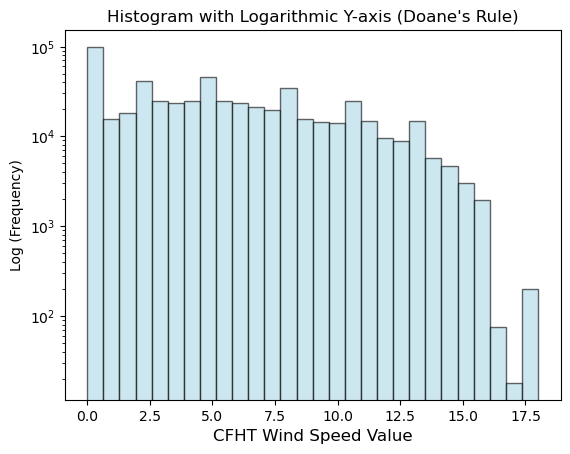

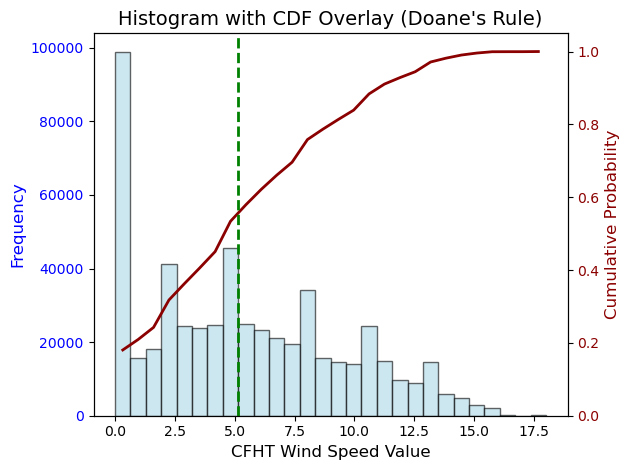

In [25]:
print("The max value is: ",round(max(CFHT_windspeed),4))
print("The min value is: ", round(min(CFHT_windspeed),4))
print("The median value is: ", round(np.median(CFHT_windspeed),4))
print("The std value is: ", round(np.std(CFHT_windspeed),4))
print("-------------")
doane_hist(CFHT_windspeed, 'CFHT Wind Speed')

### CFHT Wind Direction

The max value is:  354.0
The min value is:  0.0
The median value is:  111.0
The std value is:  98.4702
-------------
Bin 1: Range (0.00, 12.64) -> 29774 entries
Bin 2: Range (12.64, 25.29) -> 23828 entries
Bin 3: Range (25.29, 37.93) -> 32519 entries
Bin 4: Range (37.93, 50.57) -> 41943 entries
Bin 5: Range (50.57, 63.21) -> 36206 entries
Bin 6: Range (63.21, 75.86) -> 30652 entries
Bin 7: Range (75.86, 88.50) -> 32188 entries
Bin 8: Range (88.50, 101.14) -> 31530 entries
Bin 9: Range (101.14, 113.79) -> 19925 entries
Bin 10: Range (113.79, 126.43) -> 19876 entries
Bin 11: Range (126.43, 139.07) -> 18710 entries
Bin 12: Range (139.07, 151.71) -> 12584 entries
Bin 13: Range (151.71, 164.36) -> 11244 entries
Bin 14: Range (164.36, 177.00) -> 10633 entries
Bin 15: Range (177.00, 189.64) -> 9919 entries
Bin 16: Range (189.64, 202.29) -> 12571 entries
Bin 17: Range (202.29, 214.93) -> 14477 entries
Bin 18: Range (214.93, 227.57) -> 19395 entries
Bin 19: Range (227.57, 240.21) -> 24291 entri

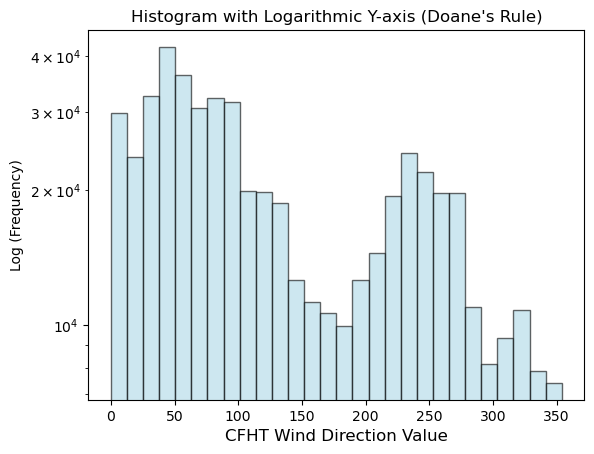

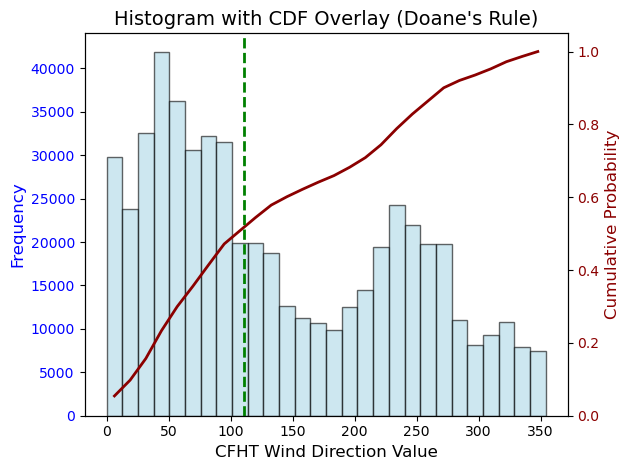

In [26]:
print("The max value is: ",round(max(CFHT_wind_direction),4))
print("The min value is: ", round(min(CFHT_wind_direction),4))
print("The median value is: ", round(np.median(CFHT_wind_direction),4))
print("The std value is: ", round(np.std(CFHT_wind_direction),4))
print("-------------")
doane_hist(CFHT_wind_direction, 'CFHT Wind Direction')

### CFHT Wind Temperature

The max value is:  9.75
The min value is:  -7.11
The median value is:  2.14
The std value is:  2.2083
-------------
Bin 1: Range (-7.11, -6.49) -> 308 entries
Bin 2: Range (-6.49, -5.86) -> 330 entries
Bin 3: Range (-5.86, -5.24) -> 313 entries
Bin 4: Range (-5.24, -4.61) -> 656 entries
Bin 5: Range (-4.61, -3.99) -> 1653 entries
Bin 6: Range (-3.99, -3.36) -> 3550 entries
Bin 7: Range (-3.36, -2.74) -> 5847 entries
Bin 8: Range (-2.74, -2.11) -> 8734 entries
Bin 9: Range (-2.11, -1.49) -> 13661 entries
Bin 10: Range (-1.49, -0.87) -> 24243 entries
Bin 11: Range (-0.87, -0.24) -> 28855 entries
Bin 12: Range (-0.24, 0.38) -> 36208 entries
Bin 13: Range (0.38, 1.01) -> 44494 entries
Bin 14: Range (1.01, 1.63) -> 56309 entries
Bin 15: Range (1.63, 2.26) -> 59991 entries
Bin 16: Range (2.26, 2.88) -> 64667 entries
Bin 17: Range (2.88, 3.51) -> 56591 entries
Bin 18: Range (3.51, 4.13) -> 50339 entries
Bin 19: Range (4.13, 4.75) -> 39637 entries
Bin 20: Range (4.75, 5.38) -> 24384 entries
Bi

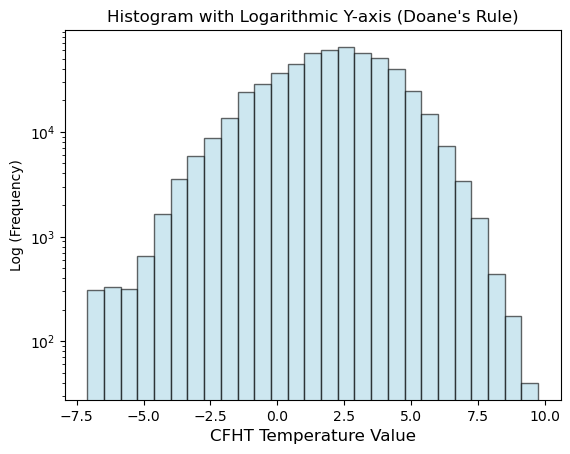

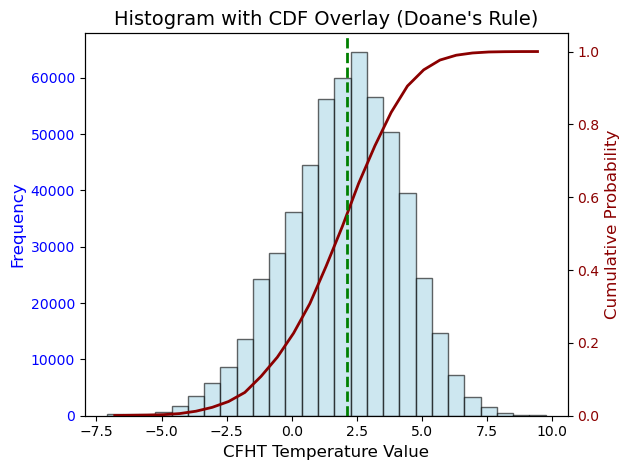

In [27]:
print("The max value is: ",round(max(CFHT_temp),4))
print("The min value is: ", round(min(CFHT_temp),4))
print("The median value is: ", round(np.median(CFHT_temp),4))
print("The std value is: ", round(np.std(CFHT_temp),4))
print("-------------")
doane_hist(CFHT_temp, 'CFHT Temperature')

### CHFT Humidity

The max value is:  94.0
The min value is:  3.0
The median value is:  15.0
The std value is:  17.5362
-------------
Bin 1: Range (3.00, 6.14) -> 56974 entries
Bin 2: Range (6.14, 9.28) -> 81234 entries
Bin 3: Range (9.28, 12.41) -> 80316 entries
Bin 4: Range (12.41, 15.55) -> 61849 entries
Bin 5: Range (15.55, 18.69) -> 41476 entries
Bin 6: Range (18.69, 21.83) -> 29320 entries
Bin 7: Range (21.83, 24.97) -> 26432 entries
Bin 8: Range (24.97, 28.10) -> 31382 entries
Bin 9: Range (28.10, 31.24) -> 18475 entries
Bin 10: Range (31.24, 34.38) -> 16127 entries
Bin 11: Range (34.38, 37.52) -> 12695 entries
Bin 12: Range (37.52, 40.66) -> 9817 entries
Bin 13: Range (40.66, 43.79) -> 9757 entries
Bin 14: Range (43.79, 46.93) -> 8655 entries
Bin 15: Range (46.93, 50.07) -> 10732 entries
Bin 16: Range (50.07, 53.21) -> 7453 entries
Bin 17: Range (53.21, 56.34) -> 7065 entries
Bin 18: Range (56.34, 59.48) -> 6465 entries
Bin 19: Range (59.48, 62.62) -> 5736 entries
Bin 20: Range (62.62, 65.76) -> 

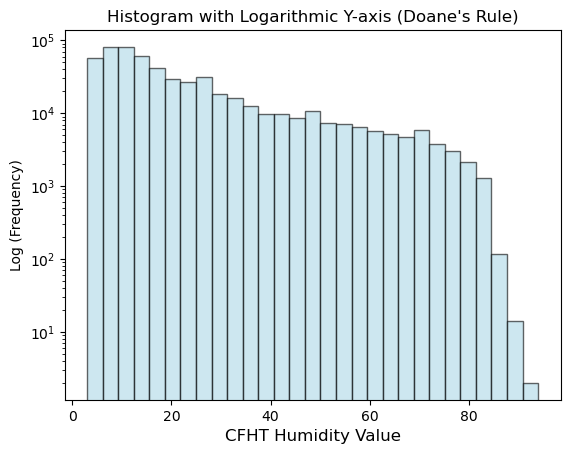

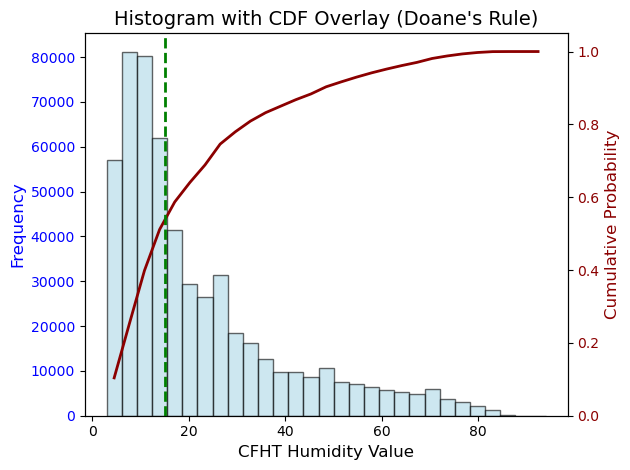

In [28]:
print("The max value is: ",round(max(CFHT_humidity),4))
print("The min value is: ", round(min(CFHT_humidity),4))
print("The median value is: ", round(np.median(CFHT_humidity),4))
print("The std value is: ", round(np.std(CFHT_humidity),4))
print("-------------")
doane_hist(CFHT_humidity, 'CFHT Humidity')

### CHFT Pressure

The max value is:  62260.0
The min value is:  60970.0
The median value is:  61800.0
The std value is:  169.8803
-------------
Bin 1: Range (60970.00, 61016.07) -> 104 entries
Bin 2: Range (61016.07, 61062.14) -> 102 entries
Bin 3: Range (61062.14, 61108.21) -> 243 entries
Bin 4: Range (61108.21, 61154.29) -> 524 entries
Bin 5: Range (61154.29, 61200.36) -> 928 entries
Bin 6: Range (61200.36, 61246.43) -> 799 entries
Bin 7: Range (61246.43, 61292.50) -> 1640 entries
Bin 8: Range (61292.50, 61338.57) -> 1849 entries
Bin 9: Range (61338.57, 61384.64) -> 3643 entries
Bin 10: Range (61384.64, 61430.71) -> 6070 entries
Bin 11: Range (61430.71, 61476.79) -> 7629 entries
Bin 12: Range (61476.79, 61522.86) -> 15639 entries
Bin 13: Range (61522.86, 61568.93) -> 16670 entries
Bin 14: Range (61568.93, 61615.00) -> 28108 entries
Bin 15: Range (61615.00, 61661.07) -> 36278 entries
Bin 16: Range (61661.07, 61707.14) -> 37501 entries
Bin 17: Range (61707.14, 61753.21) -> 59581 entries
Bin 18: Range (6

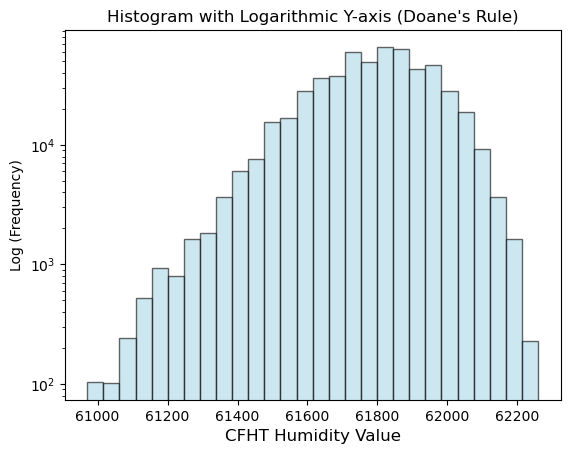

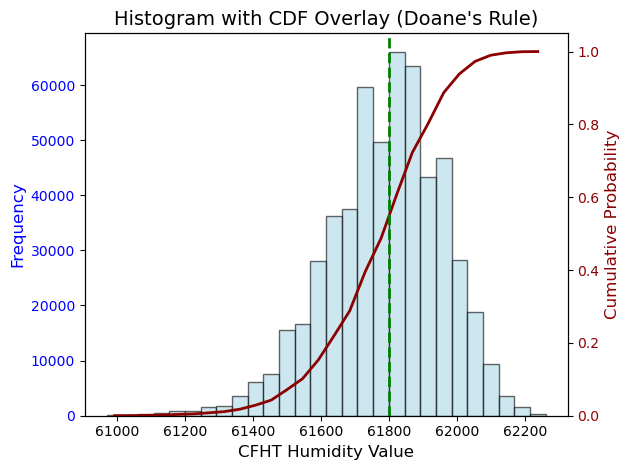

In [29]:
print("The max value is: ",round(max(CFHT_pressure),4))
print("The min value is: ", round(min(CFHT_pressure),4))
print("The median value is: ", round(np.median(CFHT_pressure),4))
print("The std value is: ", round(np.std(CFHT_pressure),4))
print("-------------")
doane_hist(CFHT_pressure, 'CFHT Humidity')